# **AI Debte on University Policy**

**Table1.DebateArguments**

In [99]:


Debate_Arguments <- data.frame(
    Argument_ID = c("A001", "A002", "A003","A004","A005","A006"),
    Position = c("For", "For", "For","Against","Against","Against"),
    Topic = c("Learning", "Productivity", "AI Literacy","Academic Integrity","Dependendency","Assessment"),
    Claim=
       c( "AI can provide students with immediate learning support.",
        "AI can help students complete routine academic tasks more efficiently.",
        "Allowing AI use can help students develop AI literacy.",
        "Undisclosed AI-generated work may create academic integrity concerns.",
        "Excessive AI Use may reduce student's independent problem-solving practive.",
        "AI use may make it more difficult to determine wehter submitted work reflects student learning.")

)

print(Debate_Arguments)

  Argument_ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against      Dependendency
6        A006  Against         Assessment
                                                                                            Claim
1                                        AI can provide students with immediate learning support.
2                          AI can help students complete routine academic tasks more efficiently.
3                                          Allowing AI use can help students develop AI literacy.
4                           Undisclosed AI-generated work may create academic integrity concerns.
5                     Excessive AI Use may reduce student's independent problem-solving practive.
6 AI use may make it more difficult to determine wehter submitted work reflects student learning.


**Table2.Evidence**

In [101]:
Evidence <-data.frame(
  Evidence = c("E001","E002","E003","E004","E005","E006"),
  Argument_ID = c("A001","A002","A003","A004","A005","A006"),
  Evidence_Type = c("Research","Research","Policy","Policy","Research","Research"),
  Strength = c("Strong","Moderate","Strong","Strong","Moderate","Strong")
)

print(Evidence)

  Evidence Argument_ID Evidence_Type Strength
1     E001        A001      Research   Strong
2     E002        A002      Research Moderate
3     E003        A003        Policy   Strong
4     E004        A004        Policy   Strong
5     E005        A005      Research Moderate
6     E006        A006      Research   Strong


**2.Count Arguments**

In [75]:
table(Debate_Arguments$Position)



Against     For 
      3       3 

In [76]:
table(Evidence$Strength)



Moderate   Strong 
       2        4 

In [77]:
nrow(Debate_Arguments)

[1] 6

**3. Connect Table Arguments and Evidence**

In [105]:
knowledge_base <- merge(
  Debate_Arguments,
  Evidence,
  by = "Argument_ID"
)

print(knowledge_base)

  Argument_ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against      Dependendency
6        A006  Against         Assessment
7        A007      For      Accessibility
8        A008  Against            Privacy
                                                                                            Claim
1                                        AI can provide students with immediate learning support.
2                          AI can help students complete routine academic tasks more efficiently.
3                                          Allowing AI use can help students develop AI literacy.
4                           Undisclosed AI-generated work may create academic integrity concerns.
5                     Excessive AI Use may reduce student's independent problem-solving practive.
6 AI use may make it more difficul

**4.Convert Evidence Strength into a Score**

In [79]:
get_score <- function(Strength){
  if (Strength == "Strong"){
    return(3)
  } else if (Strength == "Moderate"){
    return(2)
  } else if (Strength == "Weak"){
    return(1)
  } else{
    return(0)
  }

}

get_score("Strong")

[1] 3

**5.Add Evidence Scores**

In [80]:
knowledge_base$Evidence_Score <- sapply(
  knowledge_base$Strength,
  get_score
)

print(knowledge_base)

  Argument_ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against      Dependendency
6        A006  Against         Assessment
                                                                                            Claim
1                                        AI can provide students with immediate learning support.
2                          AI can help students complete routine academic tasks more efficiently.
3                                          Allowing AI use can help students develop AI literacy.
4                           Undisclosed AI-generated work may create academic integrity concerns.
5                     Excessive AI Use may reduce student's independent problem-solving practive.
6 AI use may make it more difficult to determine wehter submitted work reflects student learning.
  Evidence Evidence_

**6.Convert Evidence Score to Support**

In [81]:
classify_support <- function(score){
  if (score == 3){
    return("Strongly Supported")
  } else if (score == 2){
    return("Moderately Supported")
  } else if (score == 1){
    return("Weakly Supported")
  } else{
    return("No Support")
  }
}

classify_support(2)

[1] "Moderately Supported"

**7.Add Evidence Support**

In [82]:
knowledge_base$Support_Level <- sapply(
  knowledge_base$Evidence_Score,
  classify_support
)

print(knowledge_base)

  Argument_ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against      Dependendency
6        A006  Against         Assessment
                                                                                            Claim
1                                        AI can provide students with immediate learning support.
2                          AI can help students complete routine academic tasks more efficiently.
3                                          Allowing AI use can help students develop AI literacy.
4                           Undisclosed AI-generated work may create academic integrity concerns.
5                     Excessive AI Use may reduce student's independent problem-solving practive.
6 AI use may make it more difficult to determine wehter submitted work reflects student learning.
  Evidence Evidence_

**8.Search bt Topic**

In [83]:
search_topic <- function(topic){
  result <- subset(
    knowledge_base,
    Topic == topic
  )

  if(nrow(result) == 0){
    cat("Topic not fount")
  } else{
    print(result)
  }
}

In [89]:
search_topic("Learning")

  Argument_ID Position    Topic
1        A001      For Learning
                                                     Claim Evidence
1 AI can provide students with immediate learning support.     E001
  Evidence_Type Strength Evidence_Score      Support_Level
1      Research   Strong              3 Strongly Supported


In [100]:
Debate_Arguments <- rbind(
  Debate_Arguments,
  data.frame(
    Argument_ID = c("A007", "A008"),
    Position = c("For", "Against"),
    Topic = c("Accessibility", "Privacy"),
    Claim = c(
      "AI can provide learning support to students who need additional assistance.",
      "AI systems may raise concerns about student data privacy."
    )
  )
)

In [102]:
Evidence <- rbind(
  Evidence,
  data.frame(
    Evidence = c("E007","E008"),
    Argument_ID = c("A007","A008"),
    Evidence_Type = c("Research","Policy"),
    Strength = c("Moderate","Strong")
  )
)



In [107]:
search_topic("Privacy")

  Argument_ID Position   Topic
8        A008  Against Privacy
                                                      Claim Evidence
8 AI systems may raise concerns about student data privacy.     E008
  Evidence_Type Strength
8        Policy   Strong


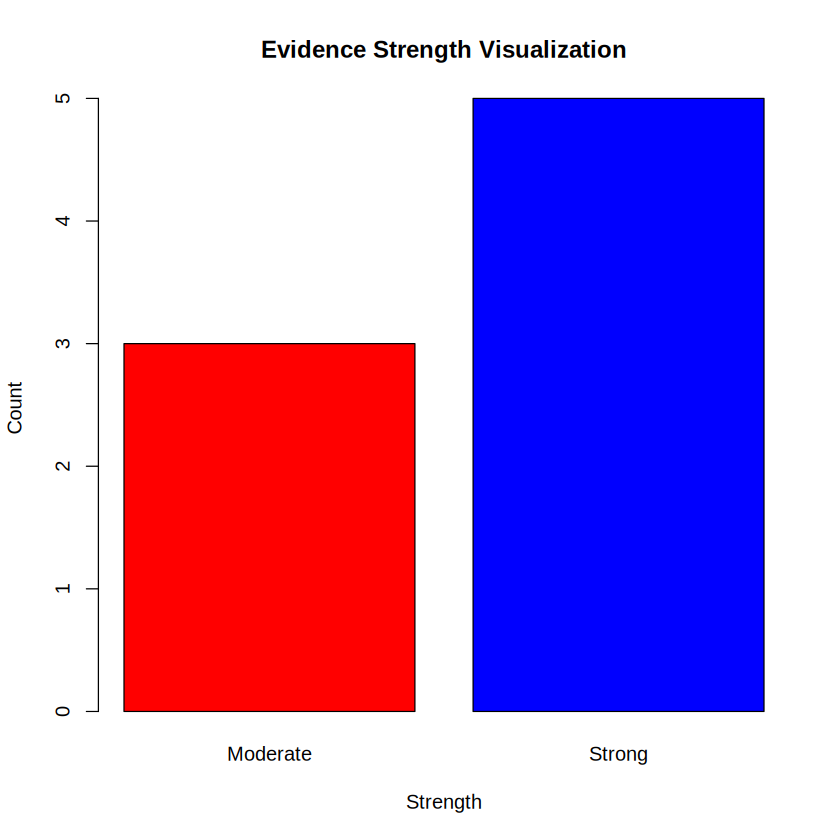

In [110]:
barplot(table(knowledge_base$Strength)
,main = "Evidence Strength Visualization",
xlab = "Strength",ylab = "Count",
col = c("red","blue"),border = "black"
)

In [108]:
table(Evidence$Strength)



Moderate   Strong 
       3        5 

In [106]:
print(Debate_Arguments)
print("=======================================")
print(Evidence)
print("====================================")
print(knowledge_base)

  Argument_ID Position              Topic
1        A001      For           Learning
2        A002      For       Productivity
3        A003      For        AI Literacy
4        A004  Against Academic Integrity
5        A005  Against      Dependendency
6        A006  Against         Assessment
7        A007      For      Accessibility
8        A008  Against            Privacy
                                                                                            Claim
1                                        AI can provide students with immediate learning support.
2                          AI can help students complete routine academic tasks more efficiently.
3                                          Allowing AI use can help students develop AI literacy.
4                           Undisclosed AI-generated work may create academic integrity concerns.
5                     Excessive AI Use may reduce student's independent problem-solving practive.
6 AI use may make it more difficul